In [89]:
import pandas as pd
import numpy as np
import rich
import matplotlib.pyplot as plt
import sklearn
import torch

from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from rich.progress import track

df = pd.read_parquet(path=r"/content/Dataset.parquet")
df["is_correct"] = df["is_correct"].astype(int)
df.shape

(3878, 13)

In [90]:
df.head(5)

,subject,question,choices,gold_answer,predicted_answer,is_correct,thinking_text,answer_start_idx,sampled_token_texts,sampled_token_logprobs,segment_names,cumulative_logprobs,top20_token_logprobs
16,abstract_algebra,"The inverse of -i in the multiplicative group,...","[1, -1, i, -i]",C,C,1,Core concept: The inverse of an element in a g...,177.0,"[<, thinking, >, \n, Core, ▁concept, :, ▁The, ...","[-5.483612312673358e-06, 0.0, 0.0, 0.0, 0.0, 0...","[structure, structure, structure, thinking, th...","[-5.483612312673358e-06, -5.483612312673358e-0...","[[-5.483612312673358e-06, -12.500005722045898,..."
21,abstract_algebra,Find the sum of the given polynomials in the g...,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",A,A,1,Core concept: Polynomial addition in Z_8[x] in...,163.0,"[<, thinking, >, \n, Core, ▁concept, :, ▁Polyn...","[-1.5497195136049413e-06, 0.0, 0.0, 0.0, 0.0, ...","[structure, structure, structure, thinking, th...","[-1.5497195136049413e-06, -1.5497195136049413e...","[[-1.5497195136049413e-06, -13.750001907348633..."
29,abstract_algebra,Statement 1 | The homomorphic image of a cycli...,"[True, True, False, False, True, False, False,...",A,A,1,Core concept: Homomorphisms preserve algebraic...,158.0,"[<, thinking, >, \n, Core, ▁concept, :, ▁Hom, ...","[-2.264974000354414e-06, 0.0, 0.0, 0.0, 0.0, 0...","[structure, structure, structure, thinking, th...","[-2.264974000354414e-06, -2.264974000354414e-0...","[[-2.264974000354414e-06, -13.250001907348633,..."
48,abstract_algebra,"Statement 1 | If a R is an integral domain, th...","[True, True, False, False, True, False, False,...",C,A,0,Core concept: The first statement concerns the...,177.0,"[<, thinking, >, \n, Core, ▁concept, :, ▁The, ...","[-1.6689286894688848e-06, 0.0, 0.0, 0.0, 0.0, ...","[structure, structure, structure, thinking, th...","[-1.6689286894688848e-06, -1.6689286894688848e...","[[-1.6689286894688848e-06, -13.625001907348633..."
54,abstract_algebra,Find the degree for the given field extension ...,"[0, 2, 1, 3]",B,B,1,Core concept: The degree of a field extension ...,187.0,"[<, thinking, >, \n, Core, ▁concept, :, ▁The, ...","[-8.106198947643861e-06, 0.0, 0.0, 0.0, 0.0, 0...","[structure, structure, structure, thinking, th...","[-8.106198947643861e-06, -8.106198947643861e-0...","[[-8.106198947643861e-06, -12.000007629394531,..."


In [91]:
num_pos = df["is_correct"].sum().item()
num_neg = len(df) - num_pos

pos_weight = num_neg / num_pos

In [92]:
MAX_LEN = 192
TOP_K = 20

In [93]:
X = []
y = []

for i in range(len(df)):
  prob_distr_collection = np.vstack(df["top20_token_logprobs"].values[i])
  if len(prob_distr_collection) < MAX_LEN:
    padding = np.array([[0.0]*TOP_K]*(MAX_LEN-len(prob_distr_collection)))
    prob_distr_collection = np.vstack([prob_distr_collection, padding])

  X.append(prob_distr_collection)
  y.append(df["is_correct"].values[i])

X = np.array(X)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train, y_train = torch.from_numpy(X_train).to(torch.float32), torch.from_numpy(y_train).to(torch.float32)
X_test, y_test = torch.from_numpy(X_test).to(torch.float32), torch.from_numpy(y_test).to(torch.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [94]:
class ConfidenceLSTM(nn.Module):
    def __init__(self, input_size=20, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        output = self.fc1(h_n[-1])
        output = self.relu(output)
        output = self.fc2(output)
        return output

In [95]:
RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)

UQ_model = ConfidenceLSTM()
UQ_model.to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = torch.optim.Adam(UQ_model.parameters(), lr=0.001)

In [96]:
loss_over_time = []
EPOCH = 150

for epoch in track(range(EPOCH), description="Training..."):
    UQ_model.train()

    y_logits = UQ_model(X_train)
    loss = criterion(y_logits, y_train.unsqueeze(dim=1))
    loss_over_time.append(loss)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Output()

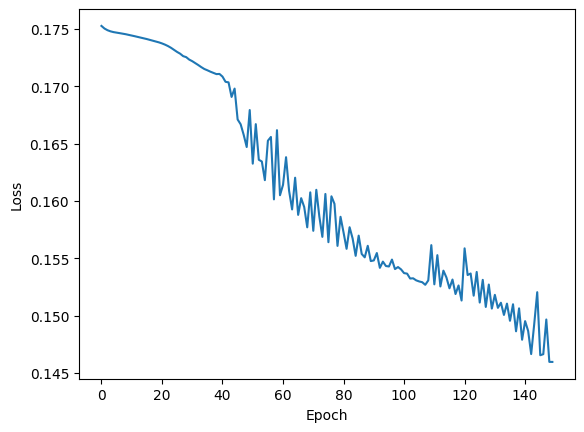

In [97]:
plt.plot(range(EPOCH), [loss.cpu().detach().numpy() for loss in loss_over_time])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [98]:
UQ_model.eval()
with torch.inference_mode():
    y_train_logits = UQ_model(X_train)
    y_train_probs = torch.sigmoid(y_train_logits)
    y_train_probs = y_train_probs.cpu().numpy()
    brier_score_train = mean_squared_error(y_train.cpu().numpy(), y_train_probs)

    y_test_logits = UQ_model(X_test)
    y_test_probs = torch.sigmoid(y_test_logits)
    y_test_probs = y_test_probs.cpu().numpy()
    brier_score_test = mean_squared_error(y_test.cpu().numpy(), y_test_probs)

In [99]:
brier_score_train

0.15776051580905914

In [100]:
brier_score_test

0.1601077765226364

In [101]:
y_train_preds = list(map(lambda x: 1 if x >= 0.5 else 0, y_train_probs))
y_test_preds = list(map(lambda x: 1 if x >= 0.5 else 0, y_test_probs))
accuracy_train = accuracy_score(y_train.cpu().numpy(), y_train_preds)
accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_preds)

In [102]:
accuracy_train

0.779819471308833

In [103]:
accuracy_test

0.7719072164948454